# Project Title: Used Car Resale Value Prediction Analysis

**Assignment**: A1  
**Name**: Jude Enuanwa  
**Student ID**: 300403859

# 2. Library Import and Data Loading

In [31]:
# Importing necessary libraries for data wrangling, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Load the unclean dataset
df = pd.read_csv('unclean_data.csv')

# Peek at the data
print("Initial Shape:", df.shape)
print("\n--- Data Info ---")
print(df.info())
df.head()

Initial Shape: (4006, 11)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3907 non-null   str    
 1   year          3904 non-null   float64
 2   price         3907 non-null   str    
 3   transmission  3907 non-null   str    
 4   mileage       3808 non-null   str    
 5   fuel type     1329 non-null   str    
 6   engine size   3842 non-null   str    
 7   mileage2      3890 non-null   str    
 8   fuel type2    3808 non-null   str    
 9   engine size2  3808 non-null   str    
 10  reference     3907 non-null   str    
dtypes: float64(1), str(10)
memory usage: 344.4 KB
None


,model,year,price,transmission,mileage,fuel type,engine size,mileage2,fuel type2,engine size2,reference
0,C Class,2020.0,"£30,495",Automatic,NaN,Diesel,2,"1,200",NaN,NaN,/ad/25017331
1,C Class,2020.0,"£29,989",Automatic,NaN,Petrol,1.5,"1,000",NaN,NaN,/ad/25043746
2,C Class,2020.0,"£37,899",Automatic,NaN,Diesel,2,500,NaN,NaN,/ad/25142894
3,C Class,2019.0,"£30,399",Automatic,NaN,Diesel,2,"5,000",NaN,NaN,/ad/24942816
4,C Class,2019.0,"£29,899",Automatic,NaN,Diesel,2,"4,500",NaN,NaN,/ad/24913660


# 3. Data Analysis, Preparation and Wrangling

## a. Handling missing rows

In [32]:
# Delete rows where all values are missing and reset index
df = df.dropna(how='all')
df = df.reset_index(drop=True)
print("Shape :", df.shape)


Shape : (3907, 11)


## b. Handling the currency symbols and comma format

In [33]:
# Handling currency and comma format
df['price'] = df['price'].astype(str).apply(lambda x: x.replace('£', '').replace(',', '').strip())

## c. Handling non-valid column names

In [34]:
# Rename non-valid column names
df.rename(columns={
    'fuel type': 'fuel_type', 
    'fuel type2': 'fuel_type2', 
    'engine size': 'engine_size', 
    'engine size2': 'engine_size2'
}, inplace=True)

## d. Handling missing values in columns: fuel_type

In [35]:
df['fuel_type2'] = df['fuel_type2'].fillna(df['fuel_type'])

df.drop('fuel_type', axis=1, inplace=True)
df.rename(columns={'fuel_type2': 'fuel_type'}, inplace=True)

## e. Handling missing values and comma format in columns: mileage

In [36]:
df['mileage'] = df.mileage.fillna(df['mileage2'])
df['mileage'] = df['mileage'].astype(str).str.replace(',', '', regex=False)
df.drop('mileage2', axis=1, inplace=True)

## f. Handling missing values and different value standard in columns: engine_size

In [37]:
df['engine_size2'] = df['engine_size2'].fillna(df['engine_size'])

df['engine_size2'] = pd.to_numeric(df['engine_size2'], errors='coerce')

df['engine_size2'] = df['engine_size2'].apply(lambda x: round(x/1000, 1) if x > 1000 else round(x, 1))
df.drop('engine_size', axis=1, inplace=True)
df.rename(columns={'engine_size2': 'engine_size'}, inplace=True)

## g. Handling wrong data type: year & cleaning remaining NaNs

In [38]:
df.dropna(inplace=True)

df['year'] = df['year'].astype('int64')

## h. Handling unneeded columns

In [39]:
df.drop(['model', 'reference'], axis=1, inplace=True)

## i. Handling categorical data

In [40]:
dummy_transmission = pd.get_dummies(df.transmission)
df = df.join(dummy_transmission)


dummy_fuel = pd.get_dummies(df.fuel_type)
dummy_fuel.rename(columns={'Other': 'Fuel_Other'}, inplace=True)
df = df.join(dummy_fuel)

## j. Saving the cleaned data into csv

In [41]:
df['mileage'] = pd.to_numeric(df.mileage, errors='coerce')
df['price'] = pd.to_numeric(df.price, errors='coerce')


print( df.shape[0])
print(df.shape[1])

df.to_csv('cleaned_data_JEn859.csv', index=False)

# df.head()

3902
14


# 4. Exploratory Data Analysis and Visualization

<Figure size 400x400 with 0 Axes>

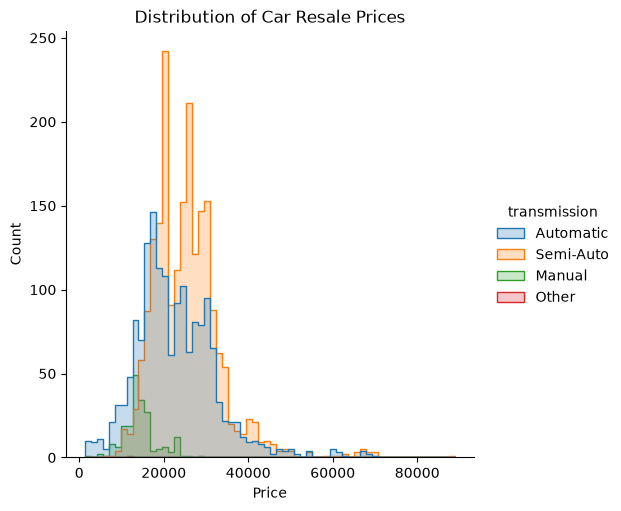

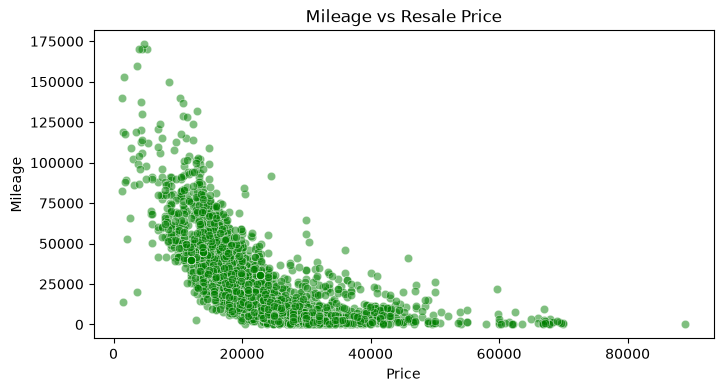

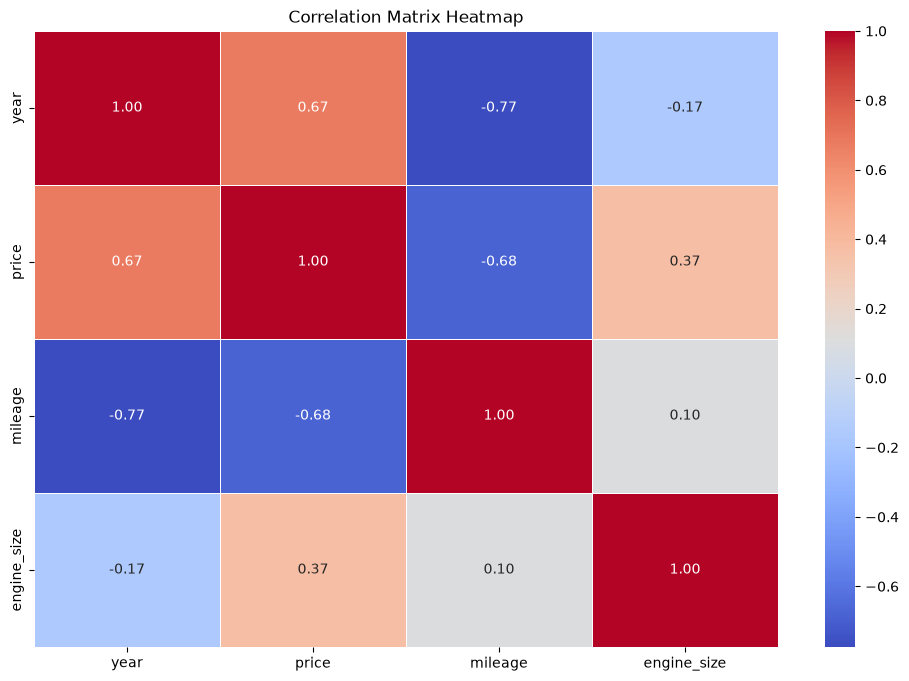

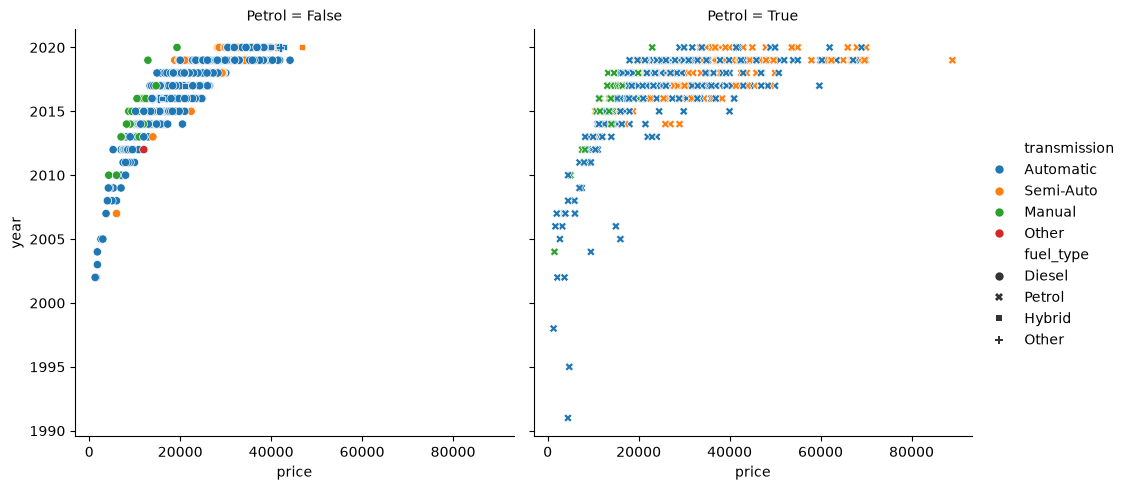

In [42]:
plt.figure(figsize=(4, 4))
sns.displot(df,x= df.price, hue='transmission',element='step')
plt.title('Distribution of Car Resale Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Scatter plot: Mileage vs Price
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='price', y='mileage', alpha=0.5, color='green')
plt.title('Mileage vs Resale Price')
plt.xlabel('Price')
plt.ylabel('Mileage')
plt.show()

# Correlation Heatmap Matrix
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

sns.relplot(
    data=df,
    x="price", y="year", col="Petrol",
    hue="transmission", style="fuel_type"
)

# 5. Feature Observation and Hypothesis

 **Observation:** Manufacturing year has the strongest positive relationship with price: newer cars reliably sell for more. Mileage shows a sharp negative relationship, reflecting how accumulated wear steadily erodes resale value. Engine_size doesn't scale smoothly with price; instead, it clusters into distinct bands that set separate pricing ceilings for performance or premium trims.
 
 **Hypothesis:** A single-variable model built on year alone should provide a reasonable starting benchmark, but depreciation isn't a straight line. The combined effects of age and mileage compound in ways linear terms can't fully capture. Moving to a multi-variable Ridge regression should boost accuracy by drawing on more of the available signal, and a higher-degree polynomial transformation should do even better at tracing the curved, non-linear pattern of how these vehicles actually lose value over time.

# 6. A Simple Linear Regression Model

RMSE: 6695.68
R2 Score: 0.4217
Coefficient: 2880.59
Intercept: -5787464.73


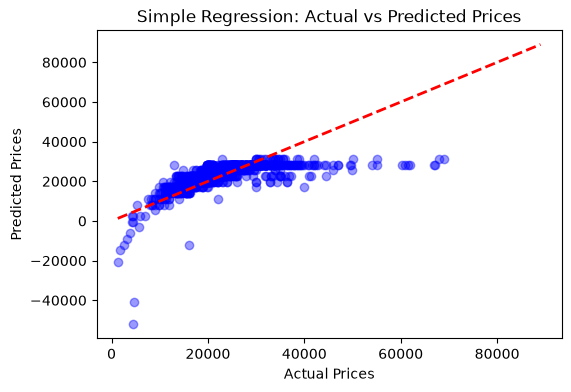

In [43]:
# Using year because it has high correlation to price
X = df[['year']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=8)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Simple Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

# 7. Linear Regression Model with Lasso/Ridge

--- Ridge Regression Results ---
Alpha Used: 1.0
RMSE: 4636.02
R2 Score: 0.7569

Model Coefficients:
year: 1953.37
mileage: -0.12
engine_size: 8498.54
Automatic: 1839.01
Manual: -1010.55
Other: -2232.35
Semi-Auto: 1403.89
Diesel: -1063.26
Hybrid: -764.74
Fuel_Other: 634.33
Petrol: 1193.67


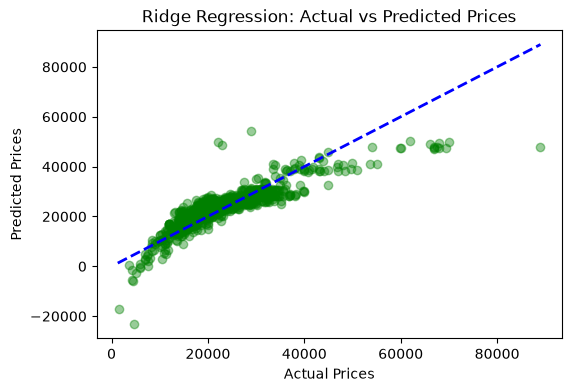

In [44]:
df.dropna(inplace=True)

X = df.drop(columns=['price', 'transmission', 'fuel_type'])
X = X.astype(float)

y = df['price'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred))
r2_r = r2_score(y_test, y_pred)

print("--- Ridge Regression Results ---")
print(f"Alpha Used: 1.0")
print(f"RMSE: {rmse_r:.2f}")
print(f"R2 Score: {r2_r:.4f}")

print("\nModel Coefficients:")
for col, coef in zip(X.columns, ridge.coef_):
    print(f"{col}: {coef:.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.4, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', lw=2)
plt.title('Ridge Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

# 8. Polynomial Regression Model (with Lasso/Ridge)

Degree: 2
Alpha: 10.0
RMSE: 3525.21
R2 Score: 0.8594


C:\Users\lenua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.8799955051536126e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


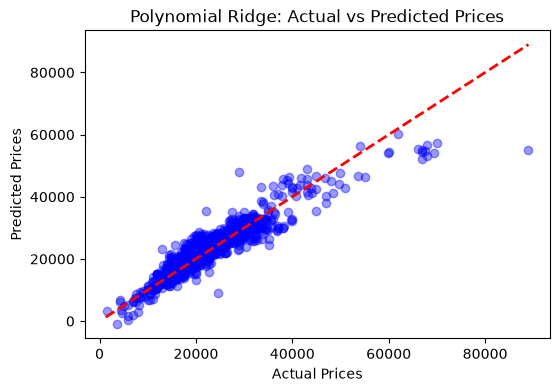

In [46]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_ridge = Ridge(alpha=10.0)
poly_ridge.fit(X_poly_train, y_train)

y_pred_p = poly_ridge.predict(X_poly_test)
rmse_p = np.sqrt(mean_squared_error(y_test, y_pred_p))
r2_p = r2_score(y_test, y_pred_p)

print(f"Degree: 2")
print(f"Alpha: 10.0")
print(f"RMSE: {rmse_p:.2f}")
print(f"R2 Score: {r2_p:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_p, alpha=0.4, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Polynomial Ridge: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()